In [1]:
# ============================================================
# PHASE 10 — FINAL MODALITY CONTRIBUTION + VISUALIZATION PACKAGE
# ============================================================
# Goals:
# 1. Analyse modality contribution:
#    - Protein-only vs Genomic-only vs Multimodal handcrafted
#    - Protein-only vs Multimodal DNABERT-2
# 2. Identify rescued/lost genes after multimodal integration.
# 3. Analyse probability/score shifts after adding genomic representation.
# 4. Prepare final publication-style tables and figures.
# 5. Consolidate Phase 7–9 outputs into a professor-ready evidence package.
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

SEED = 42
np.random.seed(SEED)

# ============================================================
# PROJECT PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Previous phases
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE7_RESULT_DIR = PHASE7_DIR / "results"
PHASE7_FIGURE_DIR = PHASE7_DIR / "figures"

PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE8_RESULT_DIR = PHASE8_DIR / "results"
PHASE8_FIGURE_DIR = PHASE8_DIR / "figures"

PHASE9_DIR = PROJECT_DIR / "model" / "phase9_dnabert2_behaviour_deep_dive"
PHASE9_RESULT_DIR = PHASE9_DIR / "results"
PHASE9_FIGURE_DIR = PHASE9_DIR / "figures"

# New Phase 10 output
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"
RESULT_DIR = PHASE10_DIR / "results"
FIGURE_DIR = PHASE10_DIR / "figures"
EXCEL_DIR = PHASE10_DIR / "excel"
REPORT_DIR = PHASE10_DIR / "reports"
GENE_LIST_DIR = PHASE10_DIR / "gene_lists"

for folder in [
    PHASE10_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    EXCEL_DIR,
    REPORT_DIR,
    GENE_LIST_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 10 output:", PHASE10_DIR)

Mounted at /content/drive
Phase 10 output: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization


In [2]:
# ============================================================
# LOAD REQUIRED TABLES
# ============================================================

def read_csv_required(path):
    path = Path(path)
    assert path.exists(), f"Missing file: {path}"
    print("Loaded:", path)
    return pd.read_csv(path)

def read_csv_optional(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Optional missing:", path)
    return pd.DataFrame()

# Phase 7
score_table_df = read_csv_required(
    PHASE7_RESULT_DIR / "phase7_unified_model_scores.csv"
)

phase7_summary_df = read_csv_required(
    PHASE7_RESULT_DIR / "phase7_model_performance_summary_with_95ci.csv"
)

phase7_focused_comparison_df = read_csv_required(
    PHASE7_RESULT_DIR / "phase7_focused_model_comparisons_for_professor.csv"
)

phase7_classification_df = read_csv_required(
    PHASE7_RESULT_DIR / "phase7_classification_metrics_default_threshold.csv"
)

# Phase 8
theme_overlap_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_curated_theme_overlap_top50_top100.csv"
)

enrichment_summary_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_expanded_enrichment_summary_by_gene_list.csv"
)

top_bio_genes_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_top100_curated_biological_genes_for_literature_review.csv"
)

# Phase 9
movement_master_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_movement_master_table_with_themes.csv"
)

stability_summary_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_top_list_stability_summary.csv"
)

moved_interpretation_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_moved_in_out_interpretation_table.csv"
)

theme_movement_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_theme_level_movement_analysis.csv"
)

priority_gene_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_priority_gene_level_interpretation_table.csv"
)

phase9_claims_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_final_interpretation_claims.csv"
)

label_shift_summary_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_rank_score_shift_by_true_label.csv"
)

print("\nScore table shape:", score_table_df.shape)
display(score_table_df.head())

Loaded: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_unified_model_scores.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_model_performance_summary_with_95ci.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_focused_model_comparisons_for_professor.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_classification_metrics_default_threshold.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_curated_theme_overlap_top50_top100.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_expanded_enrichment_summary_by_gene_list.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_top100_curated_biological_genes_for_literature_review.csv
Lo

,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score
0,ENSG00000122971,ACADS,1,593,train,ACADS,1,1151,train,True,1,ACADS,1,0.719627,0.546326,0.750810,0.744279
1,ENSG00000162104,ADCY9,1,693,train,ADCY9,1,399,train,True,1,ADCY9,1,0.680303,0.625282,0.756812,0.791051
2,ENSG00000123146,ADGRE5,0,115,train,ADGRE5,0,880,train,True,0,ADGRE5,0,0.554474,0.500000,0.532796,0.519103
3,ENSG00000172594,SMPDL3A,0,1609,test,SMPDL3A,0,617,train,True,0,SMPDL3A,0,0.683032,0.637262,0.690366,0.570216
4,ENSG00000163116,STPG2,0,159,train,STPG2,0,207,train,True,0,STPG2,0,0.237920,0.404538,0.235603,0.278157


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_gene_symbol(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()

def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df

def safe_metric(y_true, y_score, metric):
    if len(np.unique(y_true)) < 2:
        return np.nan

    if metric == "roc_auc":
        return roc_auc_score(y_true, y_score)

    if metric == "pr_auc":
        return average_precision_score(y_true, y_score)

    raise ValueError("Unsupported metric")

def classify_error(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 0:
        return "TN"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 1 and y_pred == 0:
        return "FN"
    return "UNKNOWN"

def classification_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

def get_gene_list_string(df, col="gene_symbol"):
    return ";".join(
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .drop_duplicates()
        .tolist()
    )

def export_gene_list(df, path, col="gene_symbol"):
    genes = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
    )
    genes = genes[genes != ""]
    genes = genes.drop_duplicates().tolist()

    with open(path, "w") as f:
        for gene in genes:
            f.write(gene + "\n")

    print("Saved:", path, "| n =", len(genes))

In [4]:
# ============================================================
# PREPARE FINAL MODEL SCORE TABLE
# ============================================================

required_cols = [
    "gene_id",
    "gene_symbol",
    "true_label",
    "Protein_only_ProtBERT_SW_score",
    "Genomic_only_K3K4Basic_score",
    "Multimodal_handcrafted_score",
    "Multimodal_DNABERT2_score"
]

missing = [c for c in required_cols if c not in score_table_df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

model_score_df = score_table_df[required_cols].copy()

model_score_df["gene_symbol_upper"] = model_score_df["gene_symbol"].apply(normalize_gene_symbol)
model_score_df["true_label"] = model_score_df["true_label"].astype(int)

MODEL_INFO = {
    "Protein_only_ProtBERT_SW": {
        "score_col": "Protein_only_ProtBERT_SW_score",
        "display": "Protein-only ProtBERT-SW"
    },
    "Genomic_only_K3K4Basic": {
        "score_col": "Genomic_only_K3K4Basic_score",
        "display": "Genomic-only K3/K4/Basic"
    },
    "Multimodal_handcrafted": {
        "score_col": "Multimodal_handcrafted_score",
        "display": "ProtBERT-SW + K3/K4/Basic"
    },
    "Multimodal_DNABERT2": {
        "score_col": "Multimodal_DNABERT2_score",
        "display": "ProtBERT-SW + DNABERT-2"
    }
}

# Add predictions/error type
for model_key, info in MODEL_INFO.items():
    score_col = info["score_col"]
    pred_col = f"{model_key}_pred_0p5"
    err_col = f"{model_key}_error_0p5"

    model_score_df[pred_col] = (model_score_df[score_col] >= 0.5).astype(int)
    model_score_df[err_col] = [
        classify_error(y, p)
        for y, p in zip(model_score_df["true_label"], model_score_df[pred_col])
    ]

display(model_score_df.head())

model_score_path = RESULT_DIR / "phase10_final_model_score_table.csv"
model_score_df.to_csv(model_score_path, index=False)

print("Saved:", model_score_path)

,gene_id,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,Protein_only_ProtBERT_SW_pred_0p5,Protein_only_ProtBERT_SW_error_0p5,Genomic_only_K3K4Basic_pred_0p5,Genomic_only_K3K4Basic_error_0p5,Multimodal_handcrafted_pred_0p5,Multimodal_handcrafted_error_0p5,Multimodal_DNABERT2_pred_0p5,Multimodal_DNABERT2_error_0p5
0,ENSG00000122971,ACADS,1,0.719627,0.546326,0.750810,0.744279,ACADS,1,TP,1,TP,1,TP,1,TP
1,ENSG00000162104,ADCY9,1,0.680303,0.625282,0.756812,0.791051,ADCY9,1,TP,1,TP,1,TP,1,TP
2,ENSG00000123146,ADGRE5,0,0.554474,0.500000,0.532796,0.519103,ADGRE5,1,FP,1,FP,1,FP,1,FP
3,ENSG00000172594,SMPDL3A,0,0.683032,0.637262,0.690366,0.570216,SMPDL3A,1,FP,1,FP,1,FP,1,FP
4,ENSG00000163116,STPG2,0,0.237920,0.404538,0.235603,0.278157,STPG2,0,TN,0,TN,0,TN,0,TN


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_final_model_score_table.csv


In [5]:
# ============================================================
# FINAL PERFORMANCE MASTER TABLE
# ============================================================

y_true = model_score_df["true_label"].values

performance_records = []

for model_key, info in MODEL_INFO.items():
    score = model_score_df[info["score_col"]].values

    cls = classification_metrics(y_true, score, threshold=0.5)

    performance_records.append({
        "model_key": model_key,
        "model_display": info["display"],
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        **cls
    })

performance_master_df = pd.DataFrame(performance_records)

# Add CI from Phase 7 if available
ci_cols = [
    "model_key",
    "roc_auc_ci_lower",
    "roc_auc_ci_upper",
    "pr_auc_ci_lower",
    "pr_auc_ci_upper"
]

phase7_ci_small = phase7_summary_df[[c for c in ci_cols if c in phase7_summary_df.columns]].copy()

performance_master_df = performance_master_df.merge(
    phase7_ci_small,
    on="model_key",
    how="left"
)

performance_master_df = performance_master_df.sort_values(
    by=["roc_auc", "pr_auc", "mcc"],
    ascending=False
).reset_index(drop=True)

performance_master_df = round_numeric_columns(performance_master_df, 4)

display(performance_master_df)

performance_master_path = RESULT_DIR / "phase10_final_performance_master_table.csv"
performance_master_df.to_csv(performance_master_path, index=False)

print("Saved:", performance_master_path)

,model_key,model_display,roc_auc,pr_auc,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp,roc_auc_ci_lower,roc_auc_ci_upper,pr_auc_ci_lower,pr_auc_ci_upper
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2,0.7568,0.7447,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88,0.7002,0.8108,0.6692,0.8225
1,Multimodal_handcrafted,ProtBERT-SW + K3/K4/Basic,0.7290,0.7573,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86,0.6707,0.7857,0.6893,0.8212
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT-SW,0.7274,0.7433,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92,0.6677,0.7858,0.6675,0.8175
3,Genomic_only_K3K4Basic,Genomic-only K3/K4/Basic,0.6397,0.6215,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68,0.5722,0.7045,0.5386,0.7124


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_final_performance_master_table.csv


In [6]:
# ============================================================
# SCORE SHIFT AFTER ADDING GENOMIC INFORMATION
# ============================================================

score_shift_df = model_score_df.copy()

score_shift_df["shift_handcrafted_minus_protein"] = (
    score_shift_df["Multimodal_handcrafted_score"]
    - score_shift_df["Protein_only_ProtBERT_SW_score"]
)

score_shift_df["shift_dnabert2_minus_protein"] = (
    score_shift_df["Multimodal_DNABERT2_score"]
    - score_shift_df["Protein_only_ProtBERT_SW_score"]
)

score_shift_df["shift_dnabert2_minus_handcrafted"] = (
    score_shift_df["Multimodal_DNABERT2_score"]
    - score_shift_df["Multimodal_handcrafted_score"]
)

# Rank tables
for model_key, info in MODEL_INFO.items():
    score_col = info["score_col"]
    rank_col = f"{model_key}_rank"

    score_shift_df[rank_col] = (
        score_shift_df[score_col]
        .rank(method="first", ascending=False)
        .astype(int)
    )

score_shift_df["rank_improvement_handcrafted_vs_protein"] = (
    score_shift_df["Protein_only_ProtBERT_SW_rank"]
    - score_shift_df["Multimodal_handcrafted_rank"]
)

score_shift_df["rank_improvement_dnabert2_vs_protein"] = (
    score_shift_df["Protein_only_ProtBERT_SW_rank"]
    - score_shift_df["Multimodal_DNABERT2_rank"]
)

score_shift_df["rank_improvement_dnabert2_vs_handcrafted"] = (
    score_shift_df["Multimodal_handcrafted_rank"]
    - score_shift_df["Multimodal_DNABERT2_rank"]
)

score_shift_df = round_numeric_columns(score_shift_df, 4)

display(score_shift_df.head())

score_shift_path = RESULT_DIR / "phase10_score_rank_shift_all_genes.csv"
score_shift_df.to_csv(score_shift_path, index=False)

print("Saved:", score_shift_path)

,gene_id,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,Protein_only_ProtBERT_SW_pred_0p5,Protein_only_ProtBERT_SW_error_0p5,Genomic_only_K3K4Basic_pred_0p5,Genomic_only_K3K4Basic_error_0p5,Multimodal_handcrafted_pred_0p5,Multimodal_handcrafted_error_0p5,Multimodal_DNABERT2_pred_0p5,Multimodal_DNABERT2_error_0p5,shift_handcrafted_minus_protein,shift_dnabert2_minus_protein,shift_dnabert2_minus_handcrafted,Protein_only_ProtBERT_SW_rank,Genomic_only_K3K4Basic_rank,Multimodal_handcrafted_rank,Multimodal_DNABERT2_rank,rank_improvement_handcrafted_vs_protein,rank_improvement_dnabert2_vs_protein,rank_improvement_dnabert2_vs_handcrafted
0,ENSG00000122971,ACADS,1,0.7196,0.5463,0.7508,0.7443,ACADS,1,TP,1,TP,1,TP,1,TP,0.0312,0.0247,-0.0065,39,74,34,32,5,7,2
1,ENSG00000162104,ADCY9,1,0.6803,0.6253,0.7568,0.7911,ADCY9,1,TP,1,TP,1,TP,1,TP,0.0765,0.1107,0.0342,64,29,31,9,33,55,22
2,ENSG00000123146,ADGRE5,0,0.5545,0.5000,0.5328,0.5191,ADGRE5,1,FP,1,FP,1,FP,1,FP,-0.0217,-0.0354,-0.0137,118,107,118,125,0,-7,-7
3,ENSG00000172594,SMPDL3A,0,0.6830,0.6373,0.6904,0.5702,SMPDL3A,1,FP,1,FP,1,FP,1,FP,0.0073,-0.1128,-0.1202,62,25,59,103,3,-41,-44
4,ENSG00000163116,STPG2,0,0.2379,0.4045,0.2356,0.2782,STPG2,0,TN,0,TN,0,TN,0,TN,-0.0023,0.0402,0.0426,242,203,243,229,-1,13,14


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_score_rank_shift_all_genes.csv


In [7]:
# ============================================================
# SCORE/RANK SHIFT SUMMARY BY TRUE LABEL
# ============================================================

shift_summary_records = []

shift_cols = [
    "shift_handcrafted_minus_protein",
    "shift_dnabert2_minus_protein",
    "shift_dnabert2_minus_handcrafted",
    "rank_improvement_handcrafted_vs_protein",
    "rank_improvement_dnabert2_vs_protein",
    "rank_improvement_dnabert2_vs_handcrafted"
]

for label_value, label_name in [(0, "background"), (1, "T2D-associated")]:
    sub = score_shift_df[score_shift_df["true_label"] == label_value].copy()

    record = {
        "true_label": label_value,
        "label_name": label_name,
        "n": sub.shape[0]
    }

    for col in shift_cols:
        record[f"mean_{col}"] = sub[col].mean()
        record[f"median_{col}"] = sub[col].median()

    shift_summary_records.append(record)

shift_by_label_df = pd.DataFrame(shift_summary_records)
shift_by_label_df = round_numeric_columns(shift_by_label_df, 4)

display(shift_by_label_df)

shift_by_label_path = RESULT_DIR / "phase10_score_rank_shift_by_true_label.csv"
shift_by_label_df.to_csv(shift_by_label_path, index=False)

print("Saved:", shift_by_label_path)

,true_label,label_name,n,mean_shift_handcrafted_minus_protein,median_shift_handcrafted_minus_protein,mean_shift_dnabert2_minus_protein,median_shift_dnabert2_minus_protein,mean_shift_dnabert2_minus_handcrafted,median_shift_dnabert2_minus_handcrafted,mean_rank_improvement_handcrafted_vs_protein,median_rank_improvement_handcrafted_vs_protein,mean_rank_improvement_dnabert2_vs_protein,median_rank_improvement_dnabert2_vs_protein,mean_rank_improvement_dnabert2_vs_handcrafted,median_rank_improvement_dnabert2_vs_handcrafted
0,0,background,136,-0.0090,-0.0152,-0.0123,-0.0250,-0.0033,-0.0062,-0.2132,-2.0,-3.9559,-7.5,-3.7426,-2.0
1,1,T2D-associated,135,-0.0026,0.0032,0.0055,0.0096,0.0081,0.0091,0.2148,2.0,3.9852,4.0,3.7704,4.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_score_rank_shift_by_true_label.csv


In [8]:
#Rescued gene = protein-only wrong, multimodal handcrafted correct
#Lost gene = protein-only correct, multimodal handcrafted wrong
# ============================================================
# RESCUED / LOST GENES:
# Protein-only vs Handcrafted Multimodal
# ============================================================

def compare_model_errors(df, base_model, new_model):
    base_err_col = f"{base_model}_error_0p5"
    new_err_col = f"{new_model}_error_0p5"

    base_score_col = MODEL_INFO[base_model]["score_col"]
    new_score_col = MODEL_INFO[new_model]["score_col"]

    out = df.copy()

    out["base_model"] = base_model
    out["new_model"] = new_model

    out["base_correct"] = out[base_err_col].isin(["TP", "TN"])
    out["new_correct"] = out[new_err_col].isin(["TP", "TN"])

    out["comparison_group"] = np.select(
        [
            (~out["base_correct"]) & (out["new_correct"]),
            (out["base_correct"]) & (~out["new_correct"]),
            (out["base_correct"]) & (out["new_correct"]),
            (~out["base_correct"]) & (~out["new_correct"])
        ],
        [
            "rescued_by_new_model",
            "lost_by_new_model",
            "correct_by_both",
            "wrong_by_both"
        ],
        default="unknown"
    )

    out["score_delta_new_minus_base"] = out[new_score_col] - out[base_score_col]

    return out

protein_vs_handcrafted_df = compare_model_errors(
    model_score_df,
    base_model="Protein_only_ProtBERT_SW",
    new_model="Multimodal_handcrafted"
)

protein_vs_dnabert2_df = compare_model_errors(
    model_score_df,
    base_model="Protein_only_ProtBERT_SW",
    new_model="Multimodal_DNABERT2"
)

handcrafted_vs_dnabert2_df = compare_model_errors(
    model_score_df,
    base_model="Multimodal_handcrafted",
    new_model="Multimodal_DNABERT2"
)

# Save all
protein_vs_handcrafted_df.to_csv(
    RESULT_DIR / "phase10_error_comparison_protein_vs_handcrafted.csv",
    index=False
)

protein_vs_dnabert2_df.to_csv(
    RESULT_DIR / "phase10_error_comparison_protein_vs_dnabert2.csv",
    index=False
)

handcrafted_vs_dnabert2_df.to_csv(
    RESULT_DIR / "phase10_error_comparison_handcrafted_vs_dnabert2.csv",
    index=False
)

display(protein_vs_handcrafted_df["comparison_group"].value_counts())
display(protein_vs_dnabert2_df["comparison_group"].value_counts())
display(handcrafted_vs_dnabert2_df["comparison_group"].value_counts())

,count
comparison_group,
correct_by_both,164
wrong_by_both,74
rescued_by_new_model,18
lost_by_new_model,15


,count
comparison_group,
correct_by_both,159
wrong_by_both,69
rescued_by_new_model,23
lost_by_new_model,20


,count
comparison_group,
correct_by_both,168
wrong_by_both,75
lost_by_new_model,14
rescued_by_new_model,14


In [9]:
# ============================================================
# RESCUED / LOST SUMMARY
# ============================================================

comparison_tables = {
    "Protein_to_HandcraftedMultimodal": protein_vs_handcrafted_df,
    "Protein_to_DNABERT2Multimodal": protein_vs_dnabert2_df,
    "HandcraftedMultimodal_to_DNABERT2Multimodal": handcrafted_vs_dnabert2_df,
}

rescued_lost_records = []

for comparison_name, df in comparison_tables.items():
    counts = df["comparison_group"].value_counts().to_dict()

    for group in [
        "rescued_by_new_model",
        "lost_by_new_model",
        "correct_by_both",
        "wrong_by_both"
    ]:
        sub = df[df["comparison_group"] == group].copy()

        rescued_lost_records.append({
            "comparison": comparison_name,
            "group": group,
            "n": sub.shape[0],
            "n_positive": int((sub["true_label"] == 1).sum()),
            "n_background": int((sub["true_label"] == 0).sum()),
            "mean_score_delta_new_minus_base": sub["score_delta_new_minus_base"].mean() if not sub.empty else np.nan,
            "median_score_delta_new_minus_base": sub["score_delta_new_minus_base"].median() if not sub.empty else np.nan,
            "genes": get_gene_list_string(sub, "gene_symbol") if not sub.empty else ""
        })

rescued_lost_summary_df = pd.DataFrame(rescued_lost_records)
rescued_lost_summary_df = round_numeric_columns(rescued_lost_summary_df, 4)

display(rescued_lost_summary_df)

rescued_lost_summary_path = RESULT_DIR / "phase10_rescued_lost_summary.csv"
rescued_lost_summary_df.to_csv(rescued_lost_summary_path, index=False)

print("Saved:", rescued_lost_summary_path)

,comparison,group,n,n_positive,n_background,mean_score_delta_new_minus_base,median_score_delta_new_minus_base,genes
0,Protein_to_HandcraftedMultimodal,rescued_by_new_model,18,3,15,-0.1115,-0.1148,STOX2;ANKFN1;MTNR1B;GEMIN2;KLHL7;TMEM87A;SPAG6;MIB2;CXXC1;ABCC8;PARP8;PIGT;FAM149B1;TSSK2;MFSD6L;ARPC5L;TNFRSF19;SIPA1L3
1,Protein_to_HandcraftedMultimodal,lost_by_new_model,15,9,6,-0.0266,-0.0246,ART3;PAXIP1;CDK5RAP1;PISD;TBC1D8;CHD1L;CCNH;ARHGAP22;QSOX1;TRIP10;NDUFB9;EXOC2;UCMA;PRKN;ZNF326
2,Protein_to_HandcraftedMultimodal,correct_by_both,164,83,81,0.0026,-0.0011,ACADS;ADCY9;STPG2;KCNJ11;PPP2R2C;C20orf173;NFAT5;ZBED4;MRAP;ZNF814;TFAP2B;DRC7;SLCO6A1;NOA1;GPAT4;FAM200B;NDUFA2;C12orf60;APPBP2;KIF16B;ZNF26;MED9;BIK;BCL11B;NDUFC2;GALNT10;ZNF404;PRDM5;PAMR1;MRC2;KDM2B;NOL6;ARID5B;SIRPB2;HMG20A;SAFB2;ALOXE3;CPEB3;NDUFA9;C8orf88;TSPAN8;B3GLCT;TMC3;ATG16L1;DYNC2I...
3,Protein_to_HandcraftedMultimodal,wrong_by_both,74,40,34,0.0055,0.0047,ADGRE5;SMPDL3A;HCFC2;TECPR1;TIGAR;KIF2A;G6PC2;VPS13C;PI16;CHRNA1;RPS19;SPINK2;DYNC2H1;TPK1;GTF2IRD2;TUBB4A;ZNF821;TYK2;STEAP1;PAX4;ARF3;EIF1;PARD3B;GRM7;PIP5K1A;ZBTB39;TNFAIP3;MAD1L1;WDR20;SNAPC2;EXOC1;CENPW;PRMT6;DCSTAMP;GCAT;USP44;FGGY;APOBR;RIGI;SH2B3;ADO;THADA;ANGPTL4;PSMD6;EMILIN2;BCORL1;LP...
4,Protein_to_DNABERT2Multimodal,rescued_by_new_model,23,6,17,-0.0867,-0.1061,ANKFN1;SPINK2;GEMIN2;KLHL7;TMEM87A;MIB2;CXXC1;ABCC8;PARP8;PIGT;EXOC1;FAM149B1;TSSK2;PSMD6;EMILIN2;ARPC5L;BEND3;WDR3;ANKRD55;TNFRSF19;SIPA1L3;NAA16;EXOSC2
5,Protein_to_DNABERT2Multimodal,lost_by_new_model,20,10,10,0.0198,-0.0099,ART3;PAXIP1;ZBED4;PISD;ARID5B;TBC1D8;CHD1L;MAPK8IP1;KCNK4;NDUFA13;CCNH;ARHGAP22;QSOX1;EXOC2;MYBL2;PRKN;TMEM121;HLCS;PGBD5;GSTT4
6,Protein_to_DNABERT2Multimodal,correct_by_both,159,82,77,-0.0032,0.0064,ACADS;ADCY9;STPG2;KCNJ11;PPP2R2C;C20orf173;NFAT5;MRAP;ZNF814;TFAP2B;CDK5RAP1;DRC7;SLCO6A1;NOA1;GPAT4;FAM200B;NDUFA2;C12orf60;APPBP2;KIF16B;ZNF26;MED9;BIK;BCL11B;NDUFC2;GALNT10;ZNF404;PRDM5;PAMR1;MRC2;KDM2B;NOL6;SIRPB2;HMG20A;SAFB2;ALOXE3;CPEB3;NDUFA9;C8orf88;TSPAN8;B3GLCT;TMC3;ATG16L1;DYNC2I1;TN...
7,Protein_to_DNABERT2Multimodal,wrong_by_both,69,37,32,0.0171,0.0034,ADGRE5;SMPDL3A;STOX2;HCFC2;TECPR1;TIGAR;KIF2A;G6PC2;VPS13C;PI16;CHRNA1;RPS19;MTNR1B;DYNC2H1;TPK1;GTF2IRD2;TUBB4A;ZNF821;TYK2;STEAP1;PAX4;SPAG6;ARF3;EIF1;PARD3B;GRM7;PIP5K1A;ZBTB39;TNFAIP3;MAD1L1;WDR20;SNAPC2;CENPW;PRMT6;DCSTAMP;GCAT;USP44;FGGY;APOBR;RIGI;SH2B3;ADO;THADA;ANGPTL4;BCORL1;MFSD6L;LPA...
8,HandcraftedMultimodal_to_DNABERT2Multimodal,rescued_by_new_model,14,7,7,-0.0136,-0.0100,CDK5RAP1;SPINK2;EXOC1;TRIP10;NDUFB9;PSMD6;EMILIN2;BEND3;UCMA;WDR3;ANKRD55;ZNF326;NAA16;EXOSC2
9,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,14,5,9,-0.0037,0.0256,STOX2;ZBED4;MTNR1B;ARID5B;MAPK8IP1;SPAG6;KCNK4;NDUFA13;MFSD6L;MYBL2;TMEM121;HLCS;PGBD5;GSTT4


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_rescued_lost_summary.csv


In [10]:
# ============================================================
# EXPORT RESCUED / LOST GENE LISTS
# ============================================================

for comparison_name, df in comparison_tables.items():
    for group in [
        "rescued_by_new_model",
        "lost_by_new_model",
        "wrong_by_both",
        "correct_by_both"
    ]:
        sub = df[df["comparison_group"] == group].copy()

        out_csv = RESULT_DIR / f"phase10_{comparison_name}_{group}.csv"
        out_txt = GENE_LIST_DIR / f"gene_symbols_phase10_{comparison_name}_{group}.txt"

        sub.to_csv(out_csv, index=False)
        export_gene_list(sub, out_txt, col="gene_symbol")

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/gene_lists/gene_symbols_phase10_Protein_to_HandcraftedMultimodal_rescued_by_new_model.txt | n = 18
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/gene_lists/gene_symbols_phase10_Protein_to_HandcraftedMultimodal_lost_by_new_model.txt | n = 15
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/gene_lists/gene_symbols_phase10_Protein_to_HandcraftedMultimodal_wrong_by_both.txt | n = 74
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/gene_lists/gene_symbols_phase10_Protein_to_HandcraftedMultimodal_correct_by_both.txt | n = 164
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/gene_lists/gene_symbols_phase10_Protein_to_DNABERT2Multimodal_rescued_by_new_model.txt | n = 23
Saved: /cont

In [11]:
# ============================================================
# ADD BIOLOGICAL THEMES TO RESCUED/LOST TABLES
# ============================================================

# Use themes from movement_master_df
theme_lookup = (
    movement_master_df[["gene_symbol_upper", "curated_biological_themes"]]
    .drop_duplicates("gene_symbol_upper")
    .set_index("gene_symbol_upper")["curated_biological_themes"]
    .to_dict()
)

def add_theme_support(df):
    df = df.copy()
    df["gene_symbol_upper"] = df["gene_symbol"].apply(normalize_gene_symbol)
    df["curated_biological_themes"] = df["gene_symbol_upper"].map(theme_lookup).fillna("")
    df["has_curated_theme_support"] = df["curated_biological_themes"] != ""
    return df

themed_comparison_tables = {}

for comparison_name, df in comparison_tables.items():
    themed_df = add_theme_support(df)
    themed_comparison_tables[comparison_name] = themed_df

    out_path = RESULT_DIR / f"phase10_{comparison_name}_with_biological_themes.csv"
    themed_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_Protein_to_HandcraftedMultimodal_with_biological_themes.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_Protein_to_DNABERT2Multimodal_with_biological_themes.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_with_biological_themes.csv


In [12]:
# ============================================================
# RESCUED / LOST BIOLOGICAL THEME SUMMARY
# ============================================================

theme_summary_records = []

for comparison_name, df in themed_comparison_tables.items():
    for group in [
        "rescued_by_new_model",
        "lost_by_new_model",
        "wrong_by_both",
        "correct_by_both"
    ]:
        sub = df[df["comparison_group"] == group].copy()

        theme_counts = defaultdict(int)

        for themes in sub["curated_biological_themes"].fillna(""):
            if themes.strip() == "":
                continue

            for theme in themes.split(";"):
                if theme.strip():
                    theme_counts[theme.strip()] += 1

        for theme, count in theme_counts.items():
            theme_summary_records.append({
                "comparison": comparison_name,
                "group": group,
                "theme": theme,
                "n_genes": count,
                "genes": get_gene_list_string(
                    sub[sub["curated_biological_themes"].fillna("").str.contains(theme, regex=False)],
                    "gene_symbol"
                )
            })

theme_rescued_lost_df = pd.DataFrame(theme_summary_records)

if not theme_rescued_lost_df.empty:
    theme_rescued_lost_df = theme_rescued_lost_df.sort_values(
        by=["comparison", "group", "n_genes"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

display(theme_rescued_lost_df)

theme_rescued_lost_path = RESULT_DIR / "phase10_rescued_lost_biological_theme_summary.csv"
theme_rescued_lost_df.to_csv(theme_rescued_lost_path, index=False)

print("Saved:", theme_rescued_lost_path)

,comparison,group,theme,n_genes,genes
0,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,known_t2d_gwas_or_monogenic,11,KCNJ11;HHEX;SLC5A1;INSR;ABCC8;NEUROD1;PDX1;CACNA1D;DPP4;IGF2BP2;GAD1
1,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,beta_cell_biology,8,KCNJ11;ABCC8;ISL1;NEUROD1;PDX1;CACNA1D;DPP4;GAD1
2,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,mitochondrial_function,8,NDUFA2;NDUFC2;NDUFA9;NDUFB3;NDUFB2;NDUFB1;NDUFV1;NDUFA7
3,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,oxidative_phosphorylation,8,NDUFA2;NDUFC2;NDUFA9;NDUFB3;NDUFB2;NDUFB1;NDUFV1;NDUFA7
4,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,pancreatic_development,3,ISL1;NEUROD1;PDX1
5,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,glucose_metabolism,2,SLC5A1;SLC5A2
6,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,insulin_signalling,1,INSR
7,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,lipid_metabolism,1,SCD5
8,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,known_t2d_gwas_or_monogenic,1,MTNR1B
9,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,mitochondrial_function,1,NDUFA13


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_rescued_lost_biological_theme_summary.csv


In [13]:
# ============================================================
# FINAL MODALITY CONTRIBUTION CLAIMS
# ============================================================

# Pull useful numbers
perf = performance_master_df.set_index("model_key")

def get_perf(model_key, col):
    if model_key in perf.index and col in perf.columns:
        return perf.loc[model_key, col]
    return np.nan

protein_roc = get_perf("Protein_only_ProtBERT_SW", "roc_auc")
genomic_roc = get_perf("Genomic_only_K3K4Basic", "roc_auc")
hand_roc = get_perf("Multimodal_handcrafted", "roc_auc")
dna_roc = get_perf("Multimodal_DNABERT2", "roc_auc")

protein_pr = get_perf("Protein_only_ProtBERT_SW", "pr_auc")
genomic_pr = get_perf("Genomic_only_K3K4Basic", "pr_auc")
hand_pr = get_perf("Multimodal_handcrafted", "pr_auc")
dna_pr = get_perf("Multimodal_DNABERT2", "pr_auc")

protein_mcc = get_perf("Protein_only_ProtBERT_SW", "mcc")
genomic_mcc = get_perf("Genomic_only_K3K4Basic", "mcc")
hand_mcc = get_perf("Multimodal_handcrafted", "mcc")
dna_mcc = get_perf("Multimodal_DNABERT2", "mcc")

modality_claims_df = pd.DataFrame([
    {
        "claim": "Protein embeddings are the dominant predictive signal.",
        "evidence": (
            f"Protein-only ProtBERT-SW achieved ROC-AUC={protein_roc:.4f}, "
            f"PR-AUC={protein_pr:.4f}, MCC={protein_mcc:.4f}, close to multimodal performance."
        ),
        "interpretation": (
            "Protein sequence embeddings capture strong disease-association signal, "
            "and multimodal improvement over protein-only is relatively small."
        )
    },
    {
        "claim": "Genomic-only handcrafted features contain weaker but meaningful signal.",
        "evidence": (
            f"Genomic-only K3/K4/Basic achieved ROC-AUC={genomic_roc:.4f}, "
            f"PR-AUC={genomic_pr:.4f}, MCC={genomic_mcc:.4f}, lower than protein-only and multimodal."
        ),
        "interpretation": (
            "Regulatory sequence features alone are less predictive, but they provide complementary evidence."
        )
    },
    {
        "claim": "Handcrafted multimodal integration improves false-positive control and biological interpretability.",
        "evidence": (
            f"Handcrafted multimodal achieved ROC-AUC={hand_roc:.4f}, "
            f"PR-AUC={hand_pr:.4f}, MCC={hand_mcc:.4f}; Phase 8–9 showed stronger mitochondrial/OXPHOS enrichment."
        ),
        "interpretation": (
            "The benefit of handcrafted genomic integration is not only ranking performance, "
            "but improved interpretability and concentration of biologically coherent genes."
        )
    },
    {
        "claim": "DNABERT-2 multimodal provides the strongest ROC-AUC ranking extension.",
        "evidence": (
            f"DNABERT-2 multimodal achieved ROC-AUC={dna_roc:.4f}, "
            f"PR-AUC={dna_pr:.4f}, MCC={dna_mcc:.4f}; Phase 7 showed statistically supported ROC-AUC gain over handcrafted multimodal."
        ),
        "interpretation": (
            "DNABERT-2 captures additional global ranking signal, but its biological enrichment is less concentrated."
        )
    },
    {
        "claim": "Multimodal integration should be interpreted as protein-dominant but genomically supported.",
        "evidence": (
            "Phase 7–10 results show protein-only performance close to multimodal, "
            "while genomic features alter false positives, rescued/lost cases, and biological enrichment."
        ),
        "interpretation": (
            "The final framework supports the original multi-omics objective: protein and genomic representations "
            "are complementary, but not equally strong."
        )
    }
])

display(modality_claims_df)

modality_claims_path = RESULT_DIR / "phase10_final_modality_contribution_claims.csv"
modality_claims_df.to_csv(modality_claims_path, index=False)

print("Saved:", modality_claims_path)

,claim,evidence,interpretation
0,Protein embeddings are the dominant predictive signal.,"Protein-only ProtBERT-SW achieved ROC-AUC=0.7274, PR-AUC=0.7433, MCC=0.3215, close to multimodal performance.","Protein sequence embeddings capture strong disease-association signal, and multimodal improvement over protein-only is relatively small."
1,Genomic-only handcrafted features contain weaker but meaningful signal.,"Genomic-only K3/K4/Basic achieved ROC-AUC=0.6397, PR-AUC=0.6215, MCC=0.1372, lower than protein-only and multimodal.","Regulatory sequence features alone are less predictive, but they provide complementary evidence."
2,Handcrafted multimodal integration improves false-positive control and biological interpretability.,"Handcrafted multimodal achieved ROC-AUC=0.7290, PR-AUC=0.7573, MCC=0.3438; Phase 8–9 showed stronger mitochondrial/OXPHOS enrichment.","The benefit of handcrafted genomic integration is not only ranking performance, but improved interpretability and concentration of biologically coherent genes."
3,DNABERT-2 multimodal provides the strongest ROC-AUC ranking extension.,"DNABERT-2 multimodal achieved ROC-AUC=0.7568, PR-AUC=0.7447, MCC=0.3433; Phase 7 showed statistically supported ROC-AUC gain over handcrafted multimodal.","DNABERT-2 captures additional global ranking signal, but its biological enrichment is less concentrated."
4,Multimodal integration should be interpreted as protein-dominant but genomically supported.,"Phase 7–10 results show protein-only performance close to multimodal, while genomic features alter false positives, rescued/lost cases, and biological enrichment.","The final framework supports the original multi-omics objective: protein and genomic representations are complementary, but not equally strong."


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_final_modality_contribution_claims.csv


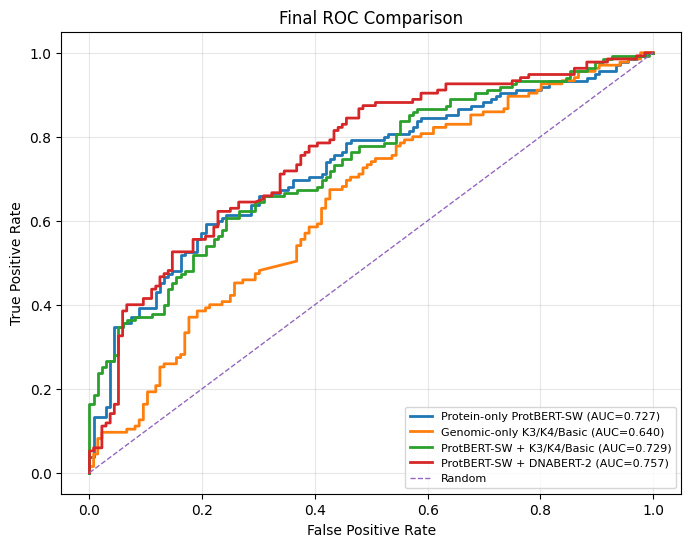

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_roc_comparison.png


In [14]:
# ============================================================
# FIGURE 1 — FINAL ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for model_key, info in MODEL_INFO.items():
    score = model_score_df[info["score_col"]].values
    fpr, tpr, _ = roc_curve(y_true, score)
    auc_val = roc_auc_score(y_true, score)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{info['display']} (AUC={auc_val:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

fig_path = FIGURE_DIR / "phase10_final_roc_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

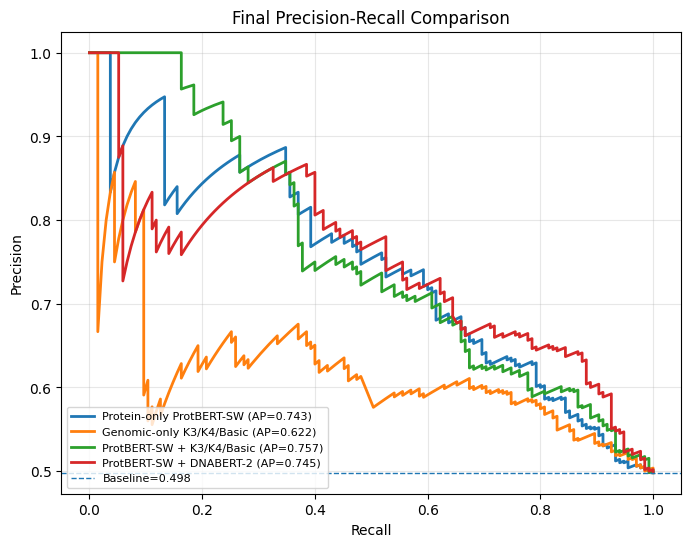

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_pr_comparison.png


In [15]:
# ============================================================
# FIGURE 2 — FINAL PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(8, 6))

baseline = np.mean(y_true)

for model_key, info in MODEL_INFO.items():
    score = model_score_df[info["score_col"]].values
    precision, recall, _ = precision_recall_curve(y_true, score)
    ap_val = average_precision_score(y_true, score)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{info['display']} (AP={ap_val:.3f})"
    )

plt.axhline(baseline, linestyle="--", linewidth=1, label=f"Baseline={baseline:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Precision-Recall Comparison")
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.3)

fig_path = FIGURE_DIR / "phase10_final_pr_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

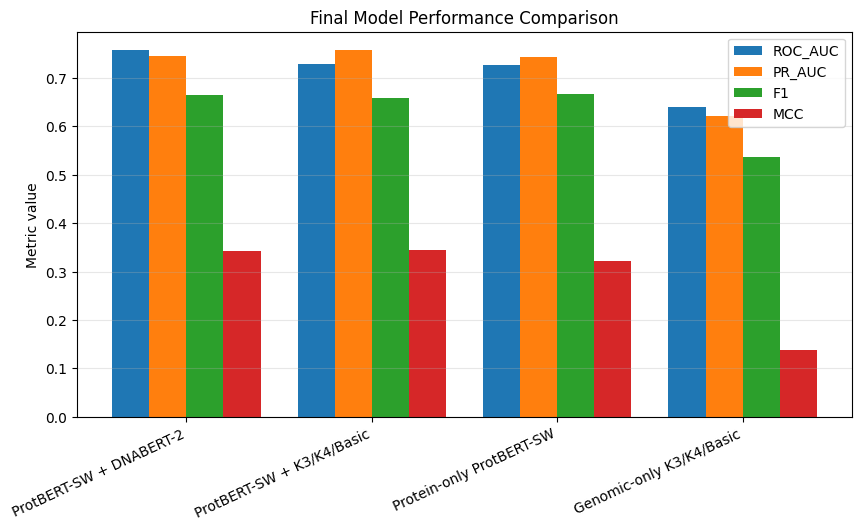

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_metric_comparison_barplot.png


In [16]:
# ============================================================
# FIGURE 3 — FINAL METRIC BAR PLOT
# ============================================================

metric_plot_df = performance_master_df.copy()

plot_metrics = ["roc_auc", "pr_auc", "f1", "mcc"]

x = np.arange(len(metric_plot_df))
width = 0.2

plt.figure(figsize=(10, 5))

for i, metric in enumerate(plot_metrics):
    plt.bar(
        x + (i - 1.5) * width,
        metric_plot_df[metric],
        width=width,
        label=metric.upper()
    )

plt.xticks(
    x,
    metric_plot_df["model_display"],
    rotation=25,
    ha="right"
)

plt.ylabel("Metric value")
plt.title("Final Model Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase10_final_metric_comparison_barplot.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

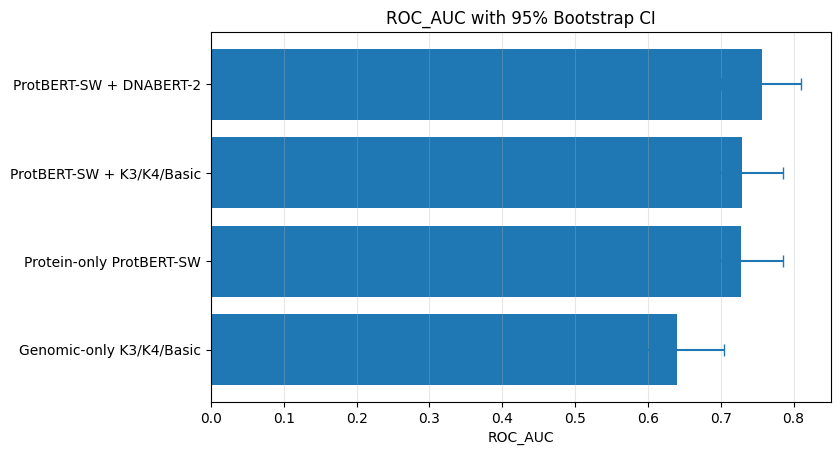

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_roc_auc_with_95ci.png


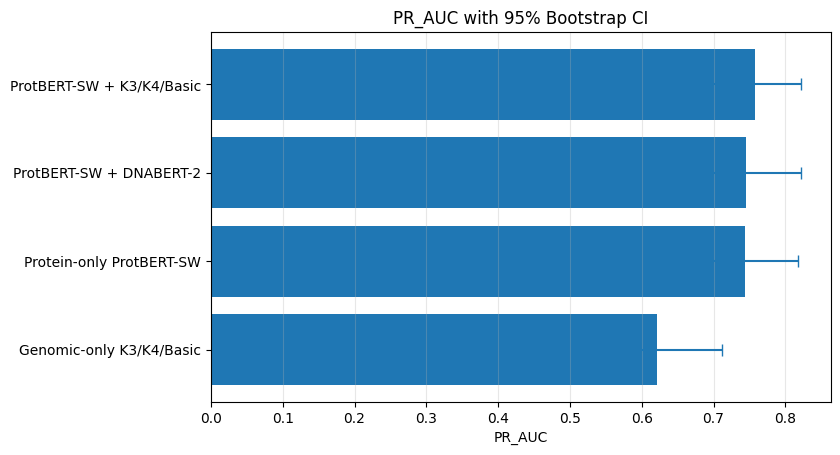

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_pr_auc_with_95ci.png


In [17]:
# ============================================================
# FIGURE 4 — ROC-AUC / PR-AUC WITH 95% CI
# ============================================================

def plot_metric_ci(df, metric, lower_col, upper_col, output_path):
    plot_df = df.sort_values(metric, ascending=True).copy()

    y_pos = np.arange(len(plot_df))
    x_val = plot_df[metric].values

    xerr_lower = x_val - plot_df[lower_col].values
    xerr_upper = plot_df[upper_col].values - x_val
    xerr = np.vstack([xerr_lower, xerr_upper])

    plt.figure(figsize=(8, 4.8))
    plt.barh(y_pos, x_val)
    plt.errorbar(
        x_val,
        y_pos,
        xerr=xerr,
        fmt="none",
        capsize=4
    )

    plt.yticks(y_pos, plot_df["model_display"])
    plt.xlabel(metric.upper())
    plt.title(f"{metric.upper()} with 95% Bootstrap CI")
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

if {"roc_auc_ci_lower", "roc_auc_ci_upper"}.issubset(performance_master_df.columns):
    plot_metric_ci(
        performance_master_df,
        metric="roc_auc",
        lower_col="roc_auc_ci_lower",
        upper_col="roc_auc_ci_upper",
        output_path=FIGURE_DIR / "phase10_roc_auc_with_95ci.png"
    )

if {"pr_auc_ci_lower", "pr_auc_ci_upper"}.issubset(performance_master_df.columns):
    plot_metric_ci(
        performance_master_df,
        metric="pr_auc",
        lower_col="pr_auc_ci_lower",
        upper_col="pr_auc_ci_upper",
        output_path=FIGURE_DIR / "phase10_pr_auc_with_95ci.png"
    )

,label_name,shift_type,mean_shift,median_shift
0,Background,Handcrafted multimodal - Protein,-0.0090,-0.0152
1,Background,DNABERT-2 multimodal - Protein,-0.0123,-0.0250
2,Background,DNABERT-2 - Handcrafted,-0.0033,-0.0062
3,T2D-associated,Handcrafted multimodal - Protein,-0.0026,0.0032
4,T2D-associated,DNABERT-2 multimodal - Protein,0.0055,0.0096
5,T2D-associated,DNABERT-2 - Handcrafted,0.0081,0.0091


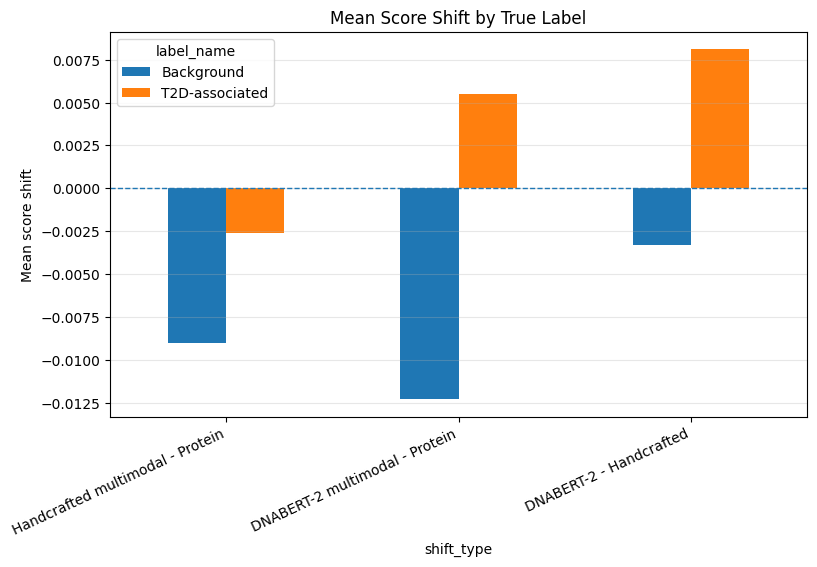

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_mean_score_shift_by_label.png


In [18]:
# ============================================================
# FIGURE 5 — SCORE SHIFT BY LABEL
# ============================================================

shift_plot_records = []

for label_value, label_name in [(0, "Background"), (1, "T2D-associated")]:
    sub = score_shift_df[score_shift_df["true_label"] == label_value].copy()

    for shift_col, display_name in [
        ("shift_handcrafted_minus_protein", "Handcrafted multimodal - Protein"),
        ("shift_dnabert2_minus_protein", "DNABERT-2 multimodal - Protein"),
        ("shift_dnabert2_minus_handcrafted", "DNABERT-2 - Handcrafted")
    ]:
        shift_plot_records.append({
            "label_name": label_name,
            "shift_type": display_name,
            "mean_shift": sub[shift_col].mean(),
            "median_shift": sub[shift_col].median()
        })

shift_plot_df = pd.DataFrame(shift_plot_records)
shift_plot_df = round_numeric_columns(shift_plot_df, 4)

display(shift_plot_df)

# Plot
pivot = shift_plot_df.pivot(
    index="shift_type",
    columns="label_name",
    values="mean_shift"
)

pivot = pivot.loc[
    [
        "Handcrafted multimodal - Protein",
        "DNABERT-2 multimodal - Protein",
        "DNABERT-2 - Handcrafted"
    ]
]

pivot.plot(kind="bar", figsize=(9, 5))
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Mean score shift")
plt.title("Mean Score Shift by True Label")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase10_mean_score_shift_by_label.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

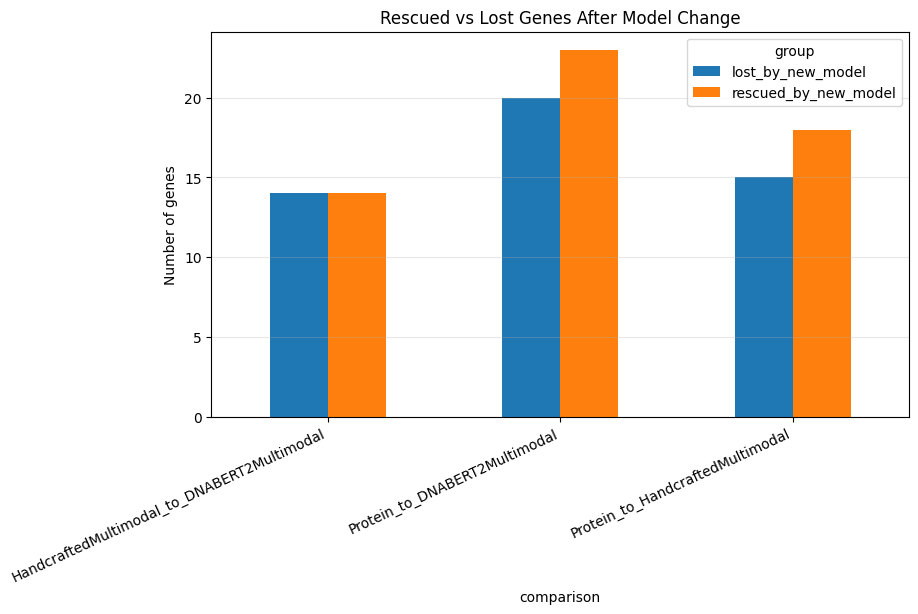

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_rescued_lost_genes_barplot.png


In [19]:
# ============================================================
# FIGURE 6 — RESCUED / LOST SUMMARY
# ============================================================

plot_df = rescued_lost_summary_df[
    rescued_lost_summary_df["group"].isin(["rescued_by_new_model", "lost_by_new_model"])
].copy()

pivot_rescue = plot_df.pivot_table(
    index="comparison",
    columns="group",
    values="n",
    aggfunc="sum"
).fillna(0)

pivot_rescue.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Number of genes")
plt.title("Rescued vs Lost Genes After Model Change")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase10_rescued_lost_genes_barplot.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

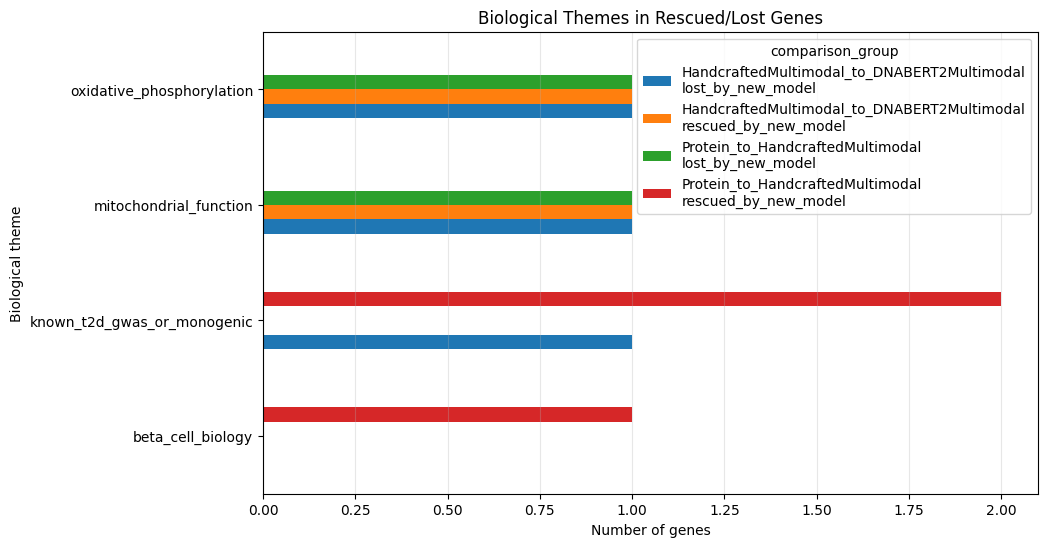

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_biological_themes_rescued_lost.png


In [20]:
# ============================================================
# FIGURE 7 — BIOLOGICAL THEMES IN RESCUED / LOST GENES
# ============================================================

# Focus on Protein -> Handcrafted and Handcrafted -> DNABERT2
focus_comparisons = [
    "Protein_to_HandcraftedMultimodal",
    "HandcraftedMultimodal_to_DNABERT2Multimodal"
]

focus_groups = ["rescued_by_new_model", "lost_by_new_model"]

theme_plot_df = theme_rescued_lost_df[
    (theme_rescued_lost_df["comparison"].isin(focus_comparisons)) &
    (theme_rescued_lost_df["group"].isin(focus_groups))
].copy()

if not theme_plot_df.empty:
    theme_plot_df["comparison_group"] = (
        theme_plot_df["comparison"] + "\n" + theme_plot_df["group"]
    )

    pivot_theme = theme_plot_df.pivot_table(
        index="theme",
        columns="comparison_group",
        values="n_genes",
        aggfunc="sum"
    ).fillna(0)

    pivot_theme = pivot_theme.loc[pivot_theme.sum(axis=1).sort_values(ascending=True).index]

    pivot_theme.plot(kind="barh", figsize=(10, 6))
    plt.xlabel("Number of genes")
    plt.ylabel("Biological theme")
    plt.title("Biological Themes in Rescued/Lost Genes")
    plt.grid(axis="x", alpha=0.3)

    fig_path = FIGURE_DIR / "phase10_biological_themes_rescued_lost.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)
else:
    print("No theme data for rescued/lost figure.")

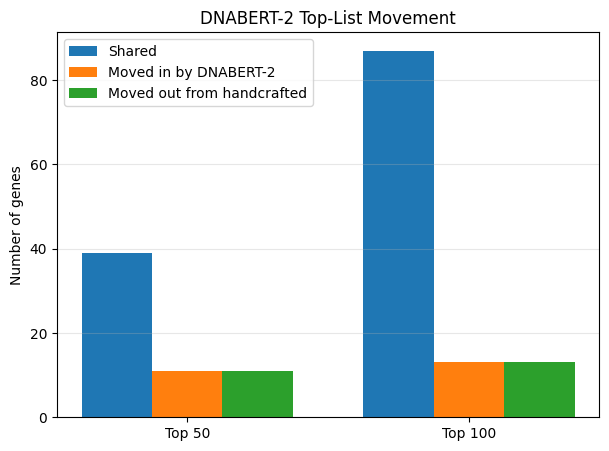

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_dnabert2_top_list_movement_summary.png


In [21]:
# ============================================================
# FIGURE 8 — DNABERT-2 TOP-LIST MOVEMENT SUMMARY
# ============================================================

movement_plot_df = stability_summary_df.copy()

x = np.arange(len(movement_plot_df))
width = 0.25

plt.figure(figsize=(7, 5))

plt.bar(
    x - width,
    movement_plot_df["shared_n"],
    width=width,
    label="Shared"
)

plt.bar(
    x,
    movement_plot_df["moved_in_by_DNABERT2_n"],
    width=width,
    label="Moved in by DNABERT-2"
)

plt.bar(
    x + width,
    movement_plot_df["moved_out_from_handcrafted_n"],
    width=width,
    label="Moved out from handcrafted"
)

plt.xticks(x, [f"Top {int(n)}" for n in movement_plot_df["top_n"]])
plt.ylabel("Number of genes")
plt.title("DNABERT-2 Top-List Movement")
plt.legend()
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase10_dnabert2_top_list_movement_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

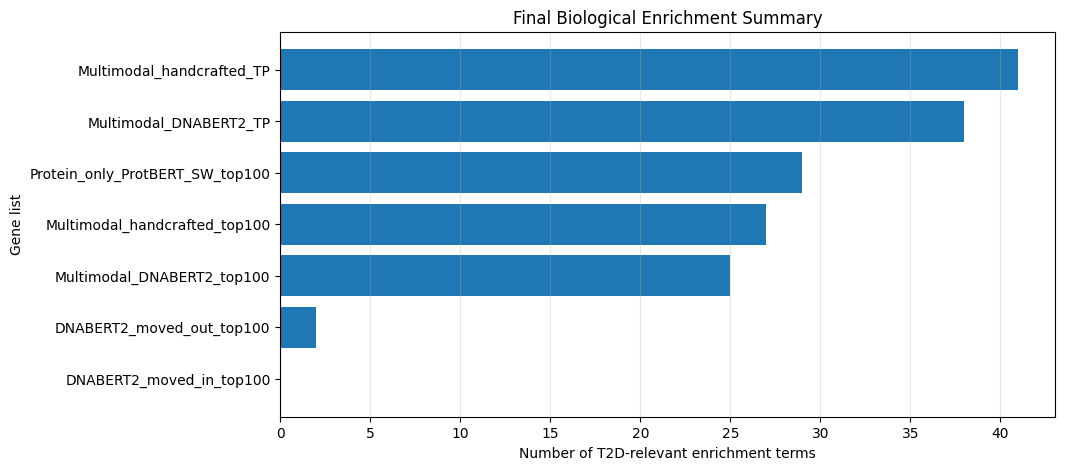

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_enrichment_summary.png


In [22]:
# ============================================================
# FIGURE 9 — FINAL ENRICHMENT SUMMARY
# ============================================================

enrich_keep = [
    "Protein_only_ProtBERT_SW_top100",
    "Multimodal_handcrafted_top100",
    "Multimodal_DNABERT2_top100",
    "Multimodal_handcrafted_TP",
    "Multimodal_DNABERT2_TP",
    "DNABERT2_moved_in_top100",
    "DNABERT2_moved_out_top100"
]

plot_enrich_df = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"].isin(enrich_keep)
].copy()

plot_enrich_df = plot_enrich_df.sort_values("n_t2d_relevant_terms", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_enrich_df["gene_list_name"], plot_enrich_df["n_t2d_relevant_terms"])
plt.xlabel("Number of T2D-relevant enrichment terms")
plt.ylabel("Gene list")
plt.title("Final Biological Enrichment Summary")
plt.grid(axis="x", alpha=0.3)

fig_path = FIGURE_DIR / "phase10_final_enrichment_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

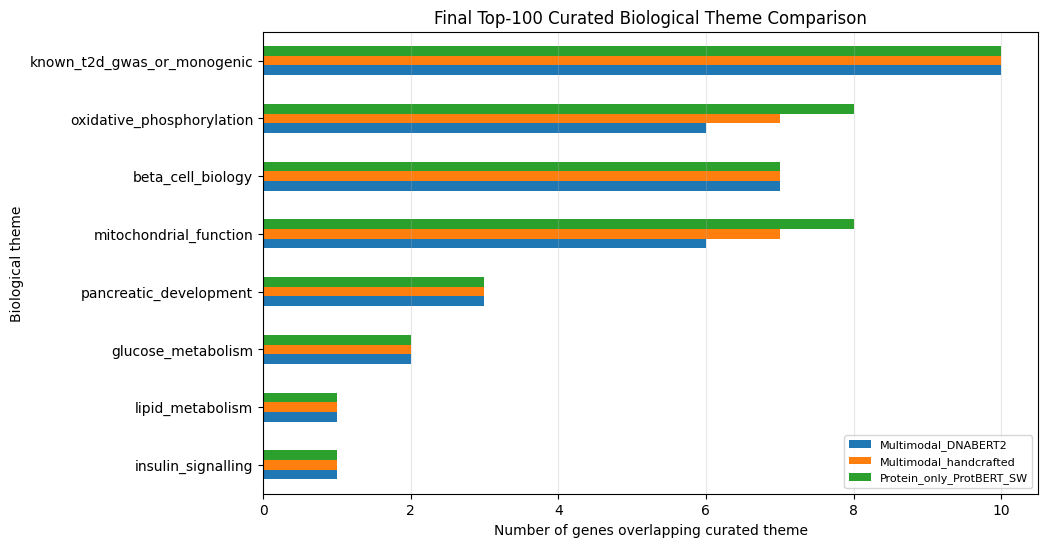

Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_theme_comparison_top100.png


In [23]:
# ============================================================
# FIGURE 10 — FINAL BIOLOGICAL THEME COMPARISON TOP100
# ============================================================

theme_top100 = theme_overlap_df[
    (theme_overlap_df["top_n"] == 100) &
    (theme_overlap_df["model_key"].isin([
        "Protein_only_ProtBERT_SW",
        "Multimodal_handcrafted",
        "Multimodal_DNABERT2"
    ]))
].copy()

pivot_theme_top100 = theme_top100.pivot_table(
    index="theme",
    columns="model_key",
    values="n_overlap",
    aggfunc="first"
).fillna(0)

pivot_theme_top100 = pivot_theme_top100.loc[
    pivot_theme_top100.sum(axis=1).sort_values(ascending=True).index
]

pivot_theme_top100.plot(kind="barh", figsize=(10, 6))

plt.xlabel("Number of genes overlapping curated theme")
plt.ylabel("Biological theme")
plt.title("Final Top-100 Curated Biological Theme Comparison")
plt.grid(axis="x", alpha=0.3)
plt.legend(fontsize=8)

fig_path = FIGURE_DIR / "phase10_final_theme_comparison_top100.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [24]:
# ============================================================
# FINAL EVIDENCE SUMMARY TABLE FOR PROFESSOR
# ============================================================

# Pull Phase 7 focused comparisons
def get_focused_delta(model_a, model_b, metric):
    sub = phase7_focused_comparison_df[
        (phase7_focused_comparison_df["model_a"] == model_a) &
        (phase7_focused_comparison_df["model_b"] == model_b) &
        (phase7_focused_comparison_df["metric"] == metric)
    ]

    if sub.empty:
        return None

    row = sub.iloc[0]

    return {
        "delta": row.get("delta_b_minus_a", np.nan),
        "ci_lower": row.get("delta_ci_lower", np.nan),
        "ci_upper": row.get("delta_ci_upper", np.nan),
        "p": row.get("p_value_bootstrap_two_sided", np.nan),
        "interpretation": row.get("interpretation", "")
    }

dna_vs_hand_roc = get_focused_delta(
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
    "roc_auc"
)

dna_vs_hand_pr = get_focused_delta(
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
    "pr_auc"
)

hand_vs_genomic_roc = get_focused_delta(
    "Genomic_only_K3K4Basic",
    "Multimodal_handcrafted",
    "roc_auc"
)

evidence_summary_df = pd.DataFrame([
    {
        "evidence_area": "Statistical evidence",
        "key_result": (
            f"DNABERT-2 multimodal achieved the highest ROC-AUC={dna_roc:.4f}; "
            f"ROC-AUC gain over handcrafted multimodal delta={dna_vs_hand_roc['delta'] if dna_vs_hand_roc else np.nan}."
        ),
        "interpretation": (
            "DNABERT-2 is the best global ranking extension, but PR-AUC improvement is not significant."
        )
    },
    {
        "evidence_area": "Protein contribution",
        "key_result": (
            f"Protein-only ROC-AUC={protein_roc:.4f}, PR-AUC={protein_pr:.4f}; "
            f"close to multimodal performance."
        ),
        "interpretation": (
            "Protein embeddings are the dominant predictive signal."
        )
    },
    {
        "evidence_area": "Genomic contribution",
        "key_result": (
            f"Genomic-only ROC-AUC={genomic_roc:.4f}; handcrafted multimodal significantly improves over genomic-only."
        ),
        "interpretation": (
            "Genomic sequence alone is weaker, but it adds complementary information in multimodal models."
        )
    },
    {
        "evidence_area": "Biological validation",
        "key_result": (
            "Handcrafted multimodal shows stronger mitochondrial/OXPHOS and curated T2D biological enrichment."
        ),
        "interpretation": (
            "Handcrafted multimodal remains the stronger biologically interpretable model."
        )
    },
    {
        "evidence_area": "DNABERT-2 behaviour",
        "key_result": (
            "DNABERT-2 moved several OXPHOS/glucose/T2D genes out of the top-ranked region, "
            "while moved-in genes showed weak/no T2D-relevant enrichment."
        ),
        "interpretation": (
            "DNABERT-2 improves global ranking but weakens top-ranked biological concentration."
        )
    },
    {
        "evidence_area": "Final model positioning",
        "key_result": (
            "Official biologically validated model: ProtBERT-SW + K3/K4/Basic. "
            "Best ROC-AUC extension: ProtBERT-SW + DNABERT-2."
        ),
        "interpretation": (
            "The final framework is protein-dominant, genomically supported, biologically validated, and extensible to DNA foundation models."
        )
    }
])

display(evidence_summary_df)

evidence_summary_path = RESULT_DIR / "phase10_final_evidence_summary_for_professor.csv"
evidence_summary_df.to_csv(evidence_summary_path, index=False)

print("Saved:", evidence_summary_path)

,evidence_area,key_result,interpretation
0,Statistical evidence,DNABERT-2 multimodal achieved the highest ROC-AUC=0.7568; ROC-AUC gain over handcrafted multimodal delta=0.0278.,"DNABERT-2 is the best global ranking extension, but PR-AUC improvement is not significant."
1,Protein contribution,"Protein-only ROC-AUC=0.7274, PR-AUC=0.7433; close to multimodal performance.",Protein embeddings are the dominant predictive signal.
2,Genomic contribution,Genomic-only ROC-AUC=0.6397; handcrafted multimodal significantly improves over genomic-only.,"Genomic sequence alone is weaker, but it adds complementary information in multimodal models."
3,Biological validation,Handcrafted multimodal shows stronger mitochondrial/OXPHOS and curated T2D biological enrichment.,Handcrafted multimodal remains the stronger biologically interpretable model.
4,DNABERT-2 behaviour,"DNABERT-2 moved several OXPHOS/glucose/T2D genes out of the top-ranked region, while moved-in genes showed weak/no T2D-relevant enrichment.",DNABERT-2 improves global ranking but weakens top-ranked biological concentration.
5,Final model positioning,Official biologically validated model: ProtBERT-SW + K3/K4/Basic. Best ROC-AUC extension: ProtBERT-SW + DNABERT-2.,"The final framework is protein-dominant, genomically supported, biologically validated, and extensible to DNA foundation models."


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_final_evidence_summary_for_professor.csv


In [25]:
# ============================================================
# FINAL FIGURE MANIFEST
# ============================================================

figure_manifest_records = []

for p in sorted(FIGURE_DIR.glob("*.png")):
    figure_manifest_records.append({
        "figure_file": p.name,
        "path": str(p),
        "suggested_use": ""
    })

figure_manifest_df = pd.DataFrame(figure_manifest_records)

# Add suggested use
suggested_use_map = {
    "phase10_final_roc_comparison.png": "Main performance comparison: ROC curves",
    "phase10_final_pr_comparison.png": "Main performance comparison: PR curves",
    "phase10_final_metric_comparison_barplot.png": "Overview of ROC-AUC, PR-AUC, F1, MCC",
    "phase10_roc_auc_with_95ci.png": "Statistical evidence: ROC-AUC with 95% CI",
    "phase10_pr_auc_with_95ci.png": "Statistical evidence: PR-AUC with 95% CI",
    "phase10_mean_score_shift_by_label.png": "Modality contribution: score shift by label",
    "phase10_rescued_lost_genes_barplot.png": "Error analysis: rescued/lost genes",
    "phase10_biological_themes_rescued_lost.png": "Explainability: biology in rescued/lost genes",
    "phase10_dnabert2_top_list_movement_summary.png": "DNABERT-2 behaviour: top-list movement",
    "phase10_final_enrichment_summary.png": "Biological validation: enrichment summary",
    "phase10_final_theme_comparison_top100.png": "Biological validation: curated theme comparison"
}

figure_manifest_df["suggested_use"] = figure_manifest_df["figure_file"].map(suggested_use_map).fillna("Supplementary figure")

display(figure_manifest_df)

figure_manifest_path = RESULT_DIR / "phase10_figure_manifest.csv"
figure_manifest_df.to_csv(figure_manifest_path, index=False)

print("Saved:", figure_manifest_path)

,figure_file,path,suggested_use
0,phase10_biological_themes_rescued_lost.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_biological_themes_rescued_lost.png,Explainability: biology in rescued/lost genes
1,phase10_dnabert2_top_list_movement_summary.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_dnabert2_top_list_movement_summary.png,DNABERT-2 behaviour: top-list movement
2,phase10_final_enrichment_summary.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_enrichment_summary.png,Biological validation: enrichment summary
3,phase10_final_metric_comparison_barplot.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_metric_comparison_barplot.png,"Overview of ROC-AUC, PR-AUC, F1, MCC"
4,phase10_final_pr_comparison.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_pr_comparison.png,Main performance comparison: PR curves
5,phase10_final_roc_comparison.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_roc_comparison.png,Main performance comparison: ROC curves
6,phase10_final_theme_comparison_top100.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_theme_comparison_top100.png,Biological validation: curated theme comparison
7,phase10_mean_score_shift_by_label.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_mean_score_shift_by_label.png,Modality contribution: score shift by label
8,phase10_pr_auc_with_95ci.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_pr_auc_with_95ci.png,Statistical evidence: PR-AUC with 95% CI
9,phase10_rescued_lost_genes_barplot.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_rescued_lost_genes_barplot.png,Error analysis: rescued/lost genes


Saved: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_figure_manifest.csv


In [26]:
# ============================================================
# EXPORT PHASE 10 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase10_final_modality_contribution_visualization_tables.xlsx"

excel_tables = {
    "Performance_Master": performance_master_df,
    "Evidence_Summary": evidence_summary_df,
    "Modality_Claims": modality_claims_df,
    "Score_Rank_Shifts": score_shift_df,
    "Shift_By_Label": shift_by_label_df,
    "Rescued_Lost_Summary": rescued_lost_summary_df,
    "Rescued_Lost_Themes": theme_rescued_lost_df,
    "Figure_Manifest": figure_manifest_df,
    "Phase7_Comparisons": phase7_focused_comparison_df,
    "Phase9_Claims": phase9_claims_df,
    "Priority_Genes": priority_gene_df,
    "Enrichment_Summary": enrichment_summary_df,
    "Theme_Top100": theme_top100,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/excel/phase10_final_modality_contribution_visualization_tables.xlsx


In [27]:
# ============================================================
# AUTO-GENERATE PHASE 10 REPORT SUMMARY
# ============================================================

# Rescued/lost key values
def get_rescue_count(comparison, group):
    sub = rescued_lost_summary_df[
        (rescued_lost_summary_df["comparison"] == comparison) &
        (rescued_lost_summary_df["group"] == group)
    ]
    if sub.empty:
        return 0
    return int(sub.iloc[0]["n"])

protein_to_hand_rescued = get_rescue_count(
    "Protein_to_HandcraftedMultimodal",
    "rescued_by_new_model"
)

protein_to_hand_lost = get_rescue_count(
    "Protein_to_HandcraftedMultimodal",
    "lost_by_new_model"
)

protein_to_dna_rescued = get_rescue_count(
    "Protein_to_DNABERT2Multimodal",
    "rescued_by_new_model"
)

protein_to_dna_lost = get_rescue_count(
    "Protein_to_DNABERT2Multimodal",
    "lost_by_new_model"
)

report_text = f"""
# Phase 10 — Final Modality Contribution and Visualization Package

## Objective

Phase 10 consolidated the final evidence package and analysed how protein and genomic representations contribute to model behaviour. This phase focused on modality contribution, score/rank shifts, rescued and lost genes, and final visualization outputs.

## Final Performance Summary

Protein-only ProtBERT-SW:
- ROC-AUC = {protein_roc:.4f}
- PR-AUC = {protein_pr:.4f}
- MCC = {protein_mcc:.4f}

Genomic-only K3/K4/Basic:
- ROC-AUC = {genomic_roc:.4f}
- PR-AUC = {genomic_pr:.4f}
- MCC = {genomic_mcc:.4f}

Handcrafted multimodal:
- ROC-AUC = {hand_roc:.4f}
- PR-AUC = {hand_pr:.4f}
- MCC = {hand_mcc:.4f}

DNABERT-2 multimodal:
- ROC-AUC = {dna_roc:.4f}
- PR-AUC = {dna_pr:.4f}
- MCC = {dna_mcc:.4f}

## Modality Contribution

Protein embeddings are the dominant predictive signal because the protein-only model remains close to multimodal performance. Genomic-only features are weaker as a standalone predictor, but multimodal models show that genomic information changes score/rank behaviour, error patterns, and biological enrichment.

## Rescued and Lost Genes

Compared with protein-only:

Handcrafted multimodal:
- Rescued genes: {protein_to_hand_rescued}
- Lost genes: {protein_to_hand_lost}

DNABERT-2 multimodal:
- Rescued genes: {protein_to_dna_rescued}
- Lost genes: {protein_to_dna_lost}

These rescued/lost genes are useful for explaining which candidates benefit from adding genomic representations.

## DNABERT-2 Behaviour

Phase 9 showed that DNABERT-2 improves global ranking but weakens biological enrichment because moved-in genes do not form a strong T2D-relevant biological cluster, while moved-out genes include mitochondrial/OXPHOS, glucose metabolism, and known T2D genes.

## Final Positioning

The official biologically validated model remains the handcrafted multimodal model:
- ProtBERT-SW protein embedding + K3/K4/Basic genomic regulatory features.

The best ROC-AUC extension is:
- ProtBERT-SW protein embedding + DNABERT-2 genomic embedding.

The overall framework can be described as:
- protein-dominant,
- genomically supported,
- statistically evaluated,
- biologically validated,
- and extensible to genomic foundation models.

## Figures Generated

Phase 10 generated final figures for:
- ROC comparison
- PR comparison
- metric comparison
- ROC-AUC/PR-AUC confidence intervals
- score shift by label
- rescued/lost genes
- biological themes in rescued/lost genes
- DNABERT-2 top-list movement
- enrichment summary
- top-100 biological theme comparison
"""

report_path = REPORT_DIR / "phase10_final_modality_contribution_visualization_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved:", report_path)


# Phase 10 — Final Modality Contribution and Visualization Package

## Objective

Phase 10 consolidated the final evidence package and analysed how protein and genomic representations contribute to model behaviour. This phase focused on modality contribution, score/rank shifts, rescued and lost genes, and final visualization outputs.

## Final Performance Summary

Protein-only ProtBERT-SW:
- ROC-AUC = 0.7274
- PR-AUC = 0.7433
- MCC = 0.3215

Genomic-only K3/K4/Basic:
- ROC-AUC = 0.6397
- PR-AUC = 0.6215
- MCC = 0.1372

Handcrafted multimodal:
- ROC-AUC = 0.7290
- PR-AUC = 0.7573
- MCC = 0.3438

DNABERT-2 multimodal:
- ROC-AUC = 0.7568
- PR-AUC = 0.7447
- MCC = 0.3433

## Modality Contribution

Protein embeddings are the dominant predictive signal because the protein-only model remains close to multimodal performance. Genomic-only features are weaker as a standalone predictor, but multimodal models show that genomic information changes score/rank behaviour, error patterns, and biologic

In [28]:
# ============================================================
# LIST PHASE 10 OUTPUTS
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\n=== GENE LIST FILES ===")
for p in sorted(GENE_LIST_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_correct_by_both.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_lost_by_new_model.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_rescued_by_new_model.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_with_biological_themes.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/phase10_HandcraftedMultimodal_to_DNABERT2Multimodal_wrong_by_both.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualizati

In [29]:
display(performance_master_df)
display(evidence_summary_df)
display(modality_claims_df)
display(shift_by_label_df)
display(rescued_lost_summary_df)
display(theme_rescued_lost_df)
display(figure_manifest_df)

,model_key,model_display,roc_auc,pr_auc,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp,roc_auc_ci_lower,roc_auc_ci_upper,pr_auc_ci_lower,pr_auc_ci_upper
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2,0.7568,0.7447,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88,0.7002,0.8108,0.6692,0.8225
1,Multimodal_handcrafted,ProtBERT-SW + K3/K4/Basic,0.7290,0.7573,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86,0.6707,0.7857,0.6893,0.8212
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT-SW,0.7274,0.7433,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92,0.6677,0.7858,0.6675,0.8175
3,Genomic_only_K3K4Basic,Genomic-only K3/K4/Basic,0.6397,0.6215,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68,0.5722,0.7045,0.5386,0.7124


,evidence_area,key_result,interpretation
0,Statistical evidence,DNABERT-2 multimodal achieved the highest ROC-AUC=0.7568; ROC-AUC gain over handcrafted multimodal delta=0.0278.,"DNABERT-2 is the best global ranking extension, but PR-AUC improvement is not significant."
1,Protein contribution,"Protein-only ROC-AUC=0.7274, PR-AUC=0.7433; close to multimodal performance.",Protein embeddings are the dominant predictive signal.
2,Genomic contribution,Genomic-only ROC-AUC=0.6397; handcrafted multimodal significantly improves over genomic-only.,"Genomic sequence alone is weaker, but it adds complementary information in multimodal models."
3,Biological validation,Handcrafted multimodal shows stronger mitochondrial/OXPHOS and curated T2D biological enrichment.,Handcrafted multimodal remains the stronger biologically interpretable model.
4,DNABERT-2 behaviour,"DNABERT-2 moved several OXPHOS/glucose/T2D genes out of the top-ranked region, while moved-in genes showed weak/no T2D-relevant enrichment.",DNABERT-2 improves global ranking but weakens top-ranked biological concentration.
5,Final model positioning,Official biologically validated model: ProtBERT-SW + K3/K4/Basic. Best ROC-AUC extension: ProtBERT-SW + DNABERT-2.,"The final framework is protein-dominant, genomically supported, biologically validated, and extensible to DNA foundation models."


,claim,evidence,interpretation
0,Protein embeddings are the dominant predictive signal.,"Protein-only ProtBERT-SW achieved ROC-AUC=0.7274, PR-AUC=0.7433, MCC=0.3215, close to multimodal performance.","Protein sequence embeddings capture strong disease-association signal, and multimodal improvement over protein-only is relatively small."
1,Genomic-only handcrafted features contain weaker but meaningful signal.,"Genomic-only K3/K4/Basic achieved ROC-AUC=0.6397, PR-AUC=0.6215, MCC=0.1372, lower than protein-only and multimodal.","Regulatory sequence features alone are less predictive, but they provide complementary evidence."
2,Handcrafted multimodal integration improves false-positive control and biological interpretability.,"Handcrafted multimodal achieved ROC-AUC=0.7290, PR-AUC=0.7573, MCC=0.3438; Phase 8–9 showed stronger mitochondrial/OXPHOS enrichment.","The benefit of handcrafted genomic integration is not only ranking performance, but improved interpretability and concentration of biologically coherent genes."
3,DNABERT-2 multimodal provides the strongest ROC-AUC ranking extension.,"DNABERT-2 multimodal achieved ROC-AUC=0.7568, PR-AUC=0.7447, MCC=0.3433; Phase 7 showed statistically supported ROC-AUC gain over handcrafted multimodal.","DNABERT-2 captures additional global ranking signal, but its biological enrichment is less concentrated."
4,Multimodal integration should be interpreted as protein-dominant but genomically supported.,"Phase 7–10 results show protein-only performance close to multimodal, while genomic features alter false positives, rescued/lost cases, and biological enrichment.","The final framework supports the original multi-omics objective: protein and genomic representations are complementary, but not equally strong."


,true_label,label_name,n,mean_shift_handcrafted_minus_protein,median_shift_handcrafted_minus_protein,mean_shift_dnabert2_minus_protein,median_shift_dnabert2_minus_protein,mean_shift_dnabert2_minus_handcrafted,median_shift_dnabert2_minus_handcrafted,mean_rank_improvement_handcrafted_vs_protein,median_rank_improvement_handcrafted_vs_protein,mean_rank_improvement_dnabert2_vs_protein,median_rank_improvement_dnabert2_vs_protein,mean_rank_improvement_dnabert2_vs_handcrafted,median_rank_improvement_dnabert2_vs_handcrafted
0,0,background,136,-0.0090,-0.0152,-0.0123,-0.0250,-0.0033,-0.0062,-0.2132,-2.0,-3.9559,-7.5,-3.7426,-2.0
1,1,T2D-associated,135,-0.0026,0.0032,0.0055,0.0096,0.0081,0.0091,0.2148,2.0,3.9852,4.0,3.7704,4.0


,comparison,group,n,n_positive,n_background,mean_score_delta_new_minus_base,median_score_delta_new_minus_base,genes
0,Protein_to_HandcraftedMultimodal,rescued_by_new_model,18,3,15,-0.1115,-0.1148,STOX2;ANKFN1;MTNR1B;GEMIN2;KLHL7;TMEM87A;SPAG6;MIB2;CXXC1;ABCC8;PARP8;PIGT;FAM149B1;TSSK2;MFSD6L;ARPC5L;TNFRSF19;SIPA1L3
1,Protein_to_HandcraftedMultimodal,lost_by_new_model,15,9,6,-0.0266,-0.0246,ART3;PAXIP1;CDK5RAP1;PISD;TBC1D8;CHD1L;CCNH;ARHGAP22;QSOX1;TRIP10;NDUFB9;EXOC2;UCMA;PRKN;ZNF326
2,Protein_to_HandcraftedMultimodal,correct_by_both,164,83,81,0.0026,-0.0011,ACADS;ADCY9;STPG2;KCNJ11;PPP2R2C;C20orf173;NFAT5;ZBED4;MRAP;ZNF814;TFAP2B;DRC7;SLCO6A1;NOA1;GPAT4;FAM200B;NDUFA2;C12orf60;APPBP2;KIF16B;ZNF26;MED9;BIK;BCL11B;NDUFC2;GALNT10;ZNF404;PRDM5;PAMR1;MRC2;KDM2B;NOL6;ARID5B;SIRPB2;HMG20A;SAFB2;ALOXE3;CPEB3;NDUFA9;C8orf88;TSPAN8;B3GLCT;TMC3;ATG16L1;DYNC2I...
3,Protein_to_HandcraftedMultimodal,wrong_by_both,74,40,34,0.0055,0.0047,ADGRE5;SMPDL3A;HCFC2;TECPR1;TIGAR;KIF2A;G6PC2;VPS13C;PI16;CHRNA1;RPS19;SPINK2;DYNC2H1;TPK1;GTF2IRD2;TUBB4A;ZNF821;TYK2;STEAP1;PAX4;ARF3;EIF1;PARD3B;GRM7;PIP5K1A;ZBTB39;TNFAIP3;MAD1L1;WDR20;SNAPC2;EXOC1;CENPW;PRMT6;DCSTAMP;GCAT;USP44;FGGY;APOBR;RIGI;SH2B3;ADO;THADA;ANGPTL4;PSMD6;EMILIN2;BCORL1;LP...
4,Protein_to_DNABERT2Multimodal,rescued_by_new_model,23,6,17,-0.0867,-0.1061,ANKFN1;SPINK2;GEMIN2;KLHL7;TMEM87A;MIB2;CXXC1;ABCC8;PARP8;PIGT;EXOC1;FAM149B1;TSSK2;PSMD6;EMILIN2;ARPC5L;BEND3;WDR3;ANKRD55;TNFRSF19;SIPA1L3;NAA16;EXOSC2
5,Protein_to_DNABERT2Multimodal,lost_by_new_model,20,10,10,0.0198,-0.0099,ART3;PAXIP1;ZBED4;PISD;ARID5B;TBC1D8;CHD1L;MAPK8IP1;KCNK4;NDUFA13;CCNH;ARHGAP22;QSOX1;EXOC2;MYBL2;PRKN;TMEM121;HLCS;PGBD5;GSTT4
6,Protein_to_DNABERT2Multimodal,correct_by_both,159,82,77,-0.0032,0.0064,ACADS;ADCY9;STPG2;KCNJ11;PPP2R2C;C20orf173;NFAT5;MRAP;ZNF814;TFAP2B;CDK5RAP1;DRC7;SLCO6A1;NOA1;GPAT4;FAM200B;NDUFA2;C12orf60;APPBP2;KIF16B;ZNF26;MED9;BIK;BCL11B;NDUFC2;GALNT10;ZNF404;PRDM5;PAMR1;MRC2;KDM2B;NOL6;SIRPB2;HMG20A;SAFB2;ALOXE3;CPEB3;NDUFA9;C8orf88;TSPAN8;B3GLCT;TMC3;ATG16L1;DYNC2I1;TN...
7,Protein_to_DNABERT2Multimodal,wrong_by_both,69,37,32,0.0171,0.0034,ADGRE5;SMPDL3A;STOX2;HCFC2;TECPR1;TIGAR;KIF2A;G6PC2;VPS13C;PI16;CHRNA1;RPS19;MTNR1B;DYNC2H1;TPK1;GTF2IRD2;TUBB4A;ZNF821;TYK2;STEAP1;PAX4;SPAG6;ARF3;EIF1;PARD3B;GRM7;PIP5K1A;ZBTB39;TNFAIP3;MAD1L1;WDR20;SNAPC2;CENPW;PRMT6;DCSTAMP;GCAT;USP44;FGGY;APOBR;RIGI;SH2B3;ADO;THADA;ANGPTL4;BCORL1;MFSD6L;LPA...
8,HandcraftedMultimodal_to_DNABERT2Multimodal,rescued_by_new_model,14,7,7,-0.0136,-0.0100,CDK5RAP1;SPINK2;EXOC1;TRIP10;NDUFB9;PSMD6;EMILIN2;BEND3;UCMA;WDR3;ANKRD55;ZNF326;NAA16;EXOSC2
9,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,14,5,9,-0.0037,0.0256,STOX2;ZBED4;MTNR1B;ARID5B;MAPK8IP1;SPAG6;KCNK4;NDUFA13;MFSD6L;MYBL2;TMEM121;HLCS;PGBD5;GSTT4


,comparison,group,theme,n_genes,genes
0,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,known_t2d_gwas_or_monogenic,11,KCNJ11;HHEX;SLC5A1;INSR;ABCC8;NEUROD1;PDX1;CACNA1D;DPP4;IGF2BP2;GAD1
1,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,beta_cell_biology,8,KCNJ11;ABCC8;ISL1;NEUROD1;PDX1;CACNA1D;DPP4;GAD1
2,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,mitochondrial_function,8,NDUFA2;NDUFC2;NDUFA9;NDUFB3;NDUFB2;NDUFB1;NDUFV1;NDUFA7
3,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,oxidative_phosphorylation,8,NDUFA2;NDUFC2;NDUFA9;NDUFB3;NDUFB2;NDUFB1;NDUFV1;NDUFA7
4,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,pancreatic_development,3,ISL1;NEUROD1;PDX1
5,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,glucose_metabolism,2,SLC5A1;SLC5A2
6,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,insulin_signalling,1,INSR
7,HandcraftedMultimodal_to_DNABERT2Multimodal,correct_by_both,lipid_metabolism,1,SCD5
8,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,known_t2d_gwas_or_monogenic,1,MTNR1B
9,HandcraftedMultimodal_to_DNABERT2Multimodal,lost_by_new_model,mitochondrial_function,1,NDUFA13


,figure_file,path,suggested_use
0,phase10_biological_themes_rescued_lost.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_biological_themes_rescued_lost.png,Explainability: biology in rescued/lost genes
1,phase10_dnabert2_top_list_movement_summary.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_dnabert2_top_list_movement_summary.png,DNABERT-2 behaviour: top-list movement
2,phase10_final_enrichment_summary.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_enrichment_summary.png,Biological validation: enrichment summary
3,phase10_final_metric_comparison_barplot.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_metric_comparison_barplot.png,"Overview of ROC-AUC, PR-AUC, F1, MCC"
4,phase10_final_pr_comparison.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_pr_comparison.png,Main performance comparison: PR curves
5,phase10_final_roc_comparison.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_roc_comparison.png,Main performance comparison: ROC curves
6,phase10_final_theme_comparison_top100.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_final_theme_comparison_top100.png,Biological validation: curated theme comparison
7,phase10_mean_score_shift_by_label.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_mean_score_shift_by_label.png,Modality contribution: score shift by label
8,phase10_pr_auc_with_95ci.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_pr_auc_with_95ci.png,Statistical evidence: PR-AUC with 95% CI
9,phase10_rescued_lost_genes_barplot.png,/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/figures/phase10_rescued_lost_genes_barplot.png,Error analysis: rescued/lost genes
